# Steam Review Surge Analysis — Stage 2: Surge Detection
### Thesis Analysis — Identifying Surge Events on the Weekly Panel

---

## Why the rolling-window approach

The original Version 2 notebook used a **global static baseline**: flag a week as a surge if
`n_reviews > game_lifetime_mean + 2 × game_lifetime_std`.

**The problem:** A game's launch week almost always dominates its review history.

**The rolling-window fix:** Compare each week against only the **preceding N weeks** of that game's own history. The baseline tracks the game's *current* activity level rather than its launch-era peak.

A rolling baseline operationalises the idea that a surge is an *unexpected* deviation from recent norms. It is this unexpectedness — not high review volume per se — that triggers the three mechanisms your thesis proposes:

1. **Player composition shift:** A surge brings in players who do not reflect the core audience, shifting pos_share regardless of underlying game quality.
2. **Expectation inflation:** Hype raised by a surge inflates player expectations before they even play, making them harder to satisfy.
3. **Information cascade:** The surge itself attracts further attention, amplifying both positive and negative sentiment signals.

A global threshold would mix in launch effects driven by entirely different mechanisms (marketing spend, novelty). Rolling isolation strips that confound away.

---

## Hyperparameters — decisions:

| Parameter | Value | What it controls |
|---|---|---|
| `WINDOW` | 8 weeks | Length of lookback baseline. Shorter = more reactive; longer = more stable. |
| `MIN_PERIODS` | 4 weeks | Minimum history before baseline is computed. Below this, std is unreliable. |
| `MULTIPLIER` | 2.0 | Standard deviations above mean to qualify as a surge. |

Robustness checks in Stage 3 should re-run with WINDOW = 4 and 12, MULTIPLIER = 1.5 and 2.5.

Answer:  Review surges reduce player satisfaction within games, an effect amplified during COVID and concentrated in mature titles, consistent with a player composition shift mechanism.


# 1. Import Libraries


In [1]:
from google.colab import drive
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

print('Libraries loaded.')

Libraries loaded.


---
# 2. Load Stage 1 Panel

Load the clean panel produced by Stage 1. Do not modify this file —
if cleaning decisions need to change, re-run Stage 1 from scratch.


In [2]:
drive.mount('/content/drive')

BASE_PATH   = 'drive/My Drive/Notebooks/PersonalResearch'
INPUT_PATH  = f'{BASE_PATH}/panel_stage1_clean.csv'
OUTPUT_PATH = f'{BASE_PATH}/panel_with_surges_weekly.csv' #original

# INPUT_PATH  = f'{BASE_PATH}/panel_stage1_lr200.csv'
# OUTPUT_PATH = f'{BASE_PATH}/panel_surges_lr200.csv'

df = pd.read_csv(
    INPUT_PATH,
    parse_dates=['year_week', 'release_date'],
    dtype={'appID': str}
)

print(f'Rows loaded      : {len(df):,}')
print(f'Unique games     : {df["appID"].nunique():,}')
print(f'Date range       : {df["year_week"].min().date()}  to  {df["year_week"].max().date()}')
print(f'Columns          : {list(df.columns)}')
df.head(3)

Mounted at /content/drive
Rows loaded      : 657,599
Unique games     : 6,396
Date range       : 2020-01-06  to  2024-12-02
Columns          : ['appID', 'name', 'iso_year', 'iso_week', 'year_week', 'n_reviews', 'pos_share', 'avg_helpful', 'release_date', 'price', 'price_tier', 'game_age_months', 'is_mature', 'lifetime_pos_share', 'total_lifetime_reviews', 'period', 'covid_period', 'inflation_period', 'post_covid_period', 'genres', 'categories']


,appID,name,iso_year,iso_week,year_week,n_reviews,pos_share,avg_helpful,release_date,price,...,game_age_months,is_mature,lifetime_pos_share,total_lifetime_reviews,period,covid_period,inflation_period,post_covid_period,genres,categories
0,1000030,"Cook, Serve, Delicious! 3?!",2020,5,2020-01-27,246,0.9837,2.7236,2020-10-14,19.9900,...,-9,False,0.9119,2089,baseline,0,0,0,"['Action', 'Indie', 'Simulation', 'Strategy']","['Single-player', 'Multi-player', 'Co-op', 'Sh..."
1,1000030,"Cook, Serve, Delicious! 3?!",2020,6,2020-02-03,87,1.0000,0.4253,2020-10-14,19.9900,...,-8,False,0.9119,2089,baseline,0,0,0,"['Action', 'Indie', 'Simulation', 'Strategy']","['Single-player', 'Multi-player', 'Co-op', 'Sh..."
2,1000030,"Cook, Serve, Delicious! 3?!",2020,7,2020-02-10,50,0.9800,4.0200,2020-10-14,19.9900,...,-8,False,0.9119,2089,baseline,0,0,0,"['Action', 'Indie', 'Simulation', 'Strategy']","['Single-player', 'Multi-player', 'Co-op', 'Sh..."


---
# 3. Sort the Panel

Sorting by `[appID, year_week]` is **non-negotiable** before any rolling computation.
If rows are out of order, the rolling window will look at the wrong weeks and
produce entirely meaningless baselines. Always sort before rolling.


In [3]:
df = df.sort_values(['appID', 'year_week']).reset_index(drop=True)
weeks_per_game = df.groupby('appID')['year_week'].nunique()

print(f'Median weeks per game : {weeks_per_game.median():.0f}')
print(f'Max weeks per game    : {weeks_per_game.max()}')
print(f'Min weeks per game    : {weeks_per_game.min()}')

Median weeks per game : 86
Max weeks per game    : 257
Min weeks per game    : 8


---
# 4. Set Hyperparameters

Define these once here. All surge detection logic below reads from these variables.
To run a robustness check, change the values here and re-run the notebook — do not
hard-code numbers inside the detection cells.


In [4]:
WINDOW      = 8
MIN_PERIODS = 8
MULTIPLIER  = 2

---
# 5. Compute the Rolling Baseline:
The rolling baseline does — for every game, every week, it asks: "given how this specific game has been performing recently, is this week unusually busy?

In [5]:
grouped = df.groupby('appID')['n_reviews']

# .shift(1) excludes current week from its own baseline (This moves every value one row forward. So this week's review count is pushed to next week's position)
df['roll_mean'] = grouped.transform(
    lambda x: x.shift(1).rolling(WINDOW, min_periods=MIN_PERIODS).mean()
)
df['roll_std'] = grouped.transform(
    lambda x: x.shift(1).rolling(WINDOW, min_periods=MIN_PERIODS).std()
)

df['surge_threshold'] = df['roll_mean'] + MULTIPLIER * df['roll_std']

# A surge requires:
# 1. A valid baseline exists (roll_mean is not NaN)
# 2. Current week exceeds the threshold
df['is_surge'] = (
    df['roll_mean'].notna() &
    (df['n_reviews'] > df['surge_threshold'])
)

n_with_baseline = df['roll_mean'].notna().sum()
n_surges        = df['is_surge'].sum()

print(f'Total rows                  : {len(df):,}')
print(f'Rows with valid baseline    : {n_with_baseline:,}')
print(f'Rows without baseline (NaN) : {df["roll_mean"].isna().sum():,}  (first {MIN_PERIODS} weeks per game)')
print(f'Surge weeks flagged         : {n_surges:,}')
print(f'Surge rate (of valid weeks) : {n_surges / n_with_baseline:.2%}')
print()
if n_surges / n_with_baseline < 0.05:
    print('WARNING: Surge rate < 5% — threshold may be too strict. Consider lowering MULTIPLIER.')
elif n_surges / n_with_baseline > 0.15:
    print('WARNING: Surge rate > 15% — threshold may be too loose. Consider raising MULTIPLIER.')
else:
    print('Surge rate is within the expected 5-15% range.')

Total rows                  : 657,599
Rows with valid baseline    : 606,431
Rows without baseline (NaN) : 51,168  (first 8 weeks per game)
Surge weeks flagged         : 46,641
Surge rate (of valid weeks) : 7.69%

Surge rate is within the expected 5-15% range.


surge rate is well within the 5–15% target range and sits almost exactly in the middle. This is a good sign — your threshold isn't too loose (flagging noise) or too strict (missing genuine events).

71,608 NaN rows out of 880,111 total (about 10%) is the expected cost. We lose roughly the first 8 weeks of every game's history, which is the price of the rolling window approach. Acceptable and expected.

Panel regression with fixed effects needs enough variation to estimate effects reliably — 70,000 surge observations across 12,000+ games is more than sufficient.

---
# 6. Surge Intensity Categories

Not all surges are equal. The thesis distinguishes moderate from extreme surges (H2).

| Category | Sigma above mean | Theoretical mechanism |
|---|---|---|
| `low` | (2σ, 3σ] | Mild anomaly — minor update, small press coverage. Small composition shift. |
| `medium` | (3σ, 4σ] | Moderate event — sale with review boost, moderate influencer coverage. |
| `large` | (4σ, 5σ] | Significant event — major patch, notable influencer stream. |
| `extreme` | > 5σ | Truly exceptional — review-bomb, viral breakout. Expectation inflation dominant. |

**Why this matters:** Each intensity category may operate through different mechanisms.
A `low` surge brings in marginally curious players (small composition shift), while an
`extreme` surge attracts highly casual or hostile reviewers, inflating expectation effects
and diluting the satisfaction signal.


In [6]:
# sigma_above computed for ALL weeks (non-surge weeks will have small or negative values)
df['sigma_above'] = np.where(
    df['roll_std'] > 0,
    (df['n_reviews'] - df['roll_mean']) / df['roll_std'],
    np.nan
)

def intensity_label(sigma):
    if pd.isna(sigma) or sigma <= MULTIPLIER:
        return 'no_surge'
    elif sigma <= 3:
        return 'low'      # 2-3 sigma
    elif sigma <= 4:
        return 'medium'   # 3-4 sigma
    elif sigma <= 5:
        return 'large'    # 4-5 sigma
    else:
        return 'extreme'  # > 5 sigma

df['surge_intensity'] = np.where(
    df['is_surge'],
    df['sigma_above'].apply(intensity_label),
    'no_surge'
)

order = ['no_surge', 'low', 'medium', 'large', 'extreme']
summary = (
    df.groupby('surge_intensity')['n_reviews']
    .agg(weeks='count', median_reviews='median', mean_reviews='mean', max_reviews='max')
    .reindex(order)
)
summary['pct_of_total'] = (summary['weeks'] / len(df) * 100).round(2)
print(summary.to_string())

                  weeks  median_reviews  mean_reviews  max_reviews  pct_of_total
surge_intensity                                                                 
no_surge         611642          5.0000       35.8708        72520       93.0100
low               19429         10.0000       42.1743         5837        2.9500
medium             9853         11.0000       50.3875        29575        1.5000
large              4599         16.0000       72.7249        15963        0.7000
extreme           12076         33.0000      178.6056        84196        1.8400


---
# 7. Handle the Zero-Std Edge Case

Some games have extremely stable low-traffic periods where `roll_std` computes to zero.
Dividing by zero produces `inf` or `NaN` in `sigma_above`.

**Decision rule:** If `roll_std == 0` and `n_reviews > roll_mean`, any increase from
a flatline is technically anomalous. We cap sigma at 10 for these rows — a large
but finite value — so they appear as `extreme` surges rather than producing errors.

Check how many rows are affected. If it is a large fraction, the minimum lifetime
reviews filter in Stage 1 may need tightening.


In [7]:
zero_std_mask = (df['roll_std'] == 0) & df['roll_mean'].notna()
n_zero_std = zero_std_mask.sum()

print(f'Rows with roll_std == 0 (flatline baseline) : {n_zero_std:,}')
print(f'As % of rows with a valid baseline          : {n_zero_std / n_with_baseline:.2%}')

if n_zero_std / n_with_baseline > 0.01:
    print('WARNING: >1% flatline rows — consider raising MIN_LIFETIME_REVIEWS in Stage 1.')
else:
    print('Flatline rows are a small fraction — acceptable.')

# Cap sigma at 10 for flatline rows to prevent inf
df.loc[zero_std_mask & (df['n_reviews'] > df['roll_mean']), 'sigma_above'] = 10.0
df.loc[zero_std_mask & (df['n_reviews'] <= df['roll_mean']), 'sigma_above'] = 0.0

# Re-apply intensity label after correction
df.loc[df['is_surge'], 'surge_intensity'] = (
    df.loc[df['is_surge'], 'sigma_above'].apply(intensity_label)
)

print('\nUpdated surge intensity distribution:')
print(df['surge_intensity'].value_counts().reindex(order))

Rows with roll_std == 0 (flatline baseline) : 3,109
As % of rows with a valid baseline          : 0.51%
Flatline rows are a small fraction — acceptable.

Updated surge intensity distribution:
surge_intensity
no_surge    610958
low          19429
medium        9853
large         4599
extreme      12760
Name: count, dtype: int64


In [8]:
extreme_weeks = df[df['surge_intensity'] == 'extreme']
top_weeks = (
    extreme_weeks.groupby('year_week')
    .agg(n_games=('appID', 'nunique'))
    .sort_values('n_games', ascending=False)
    .head(5)
)
print(top_weeks)

            n_games
year_week          
2023-11-20     1006
2022-11-21      904
2021-11-22      673
2020-11-23      619
2024-11-25      379


As a validation of the surge detection methodology, the five weeks with the highest simultaneous surge rates across games correspond precisely to Steam's annual Autumn Sale in November across all five years of the sample (2020–2024), with between 379 and 1,006 games flagged as surging simultaneously in those weeks. This confirms the rolling window baseline is correctly identifying genuine deviations from game-specific norms rather than artefacts of the data construction. Platform-wide sale effects of this kind are absorbed by week fixed effects in the panel regression and do not bias the surge intensity estimates.



---
# 8. Diagnostics — Sanity Check the Detection

Three checks before proceeding to regression:

1. **Surge rate over time** — should be relatively stable; sharp spikes suggest
   platform-wide events driving simultaneous surges across games.
2. **Spot-check on a specific game** — do flagged weeks correspond to real events?
   This is a qualitative validity check essential for defending your methodology.


## 8.1 Diagnostic 1 — Surge Rate Over Time

Are surges evenly distributed across 2020–2024, or clustered?
Clustering around specific weeks suggests platform-wide events (Steam sales, major releases)
are driving simultaneous surges across many games.

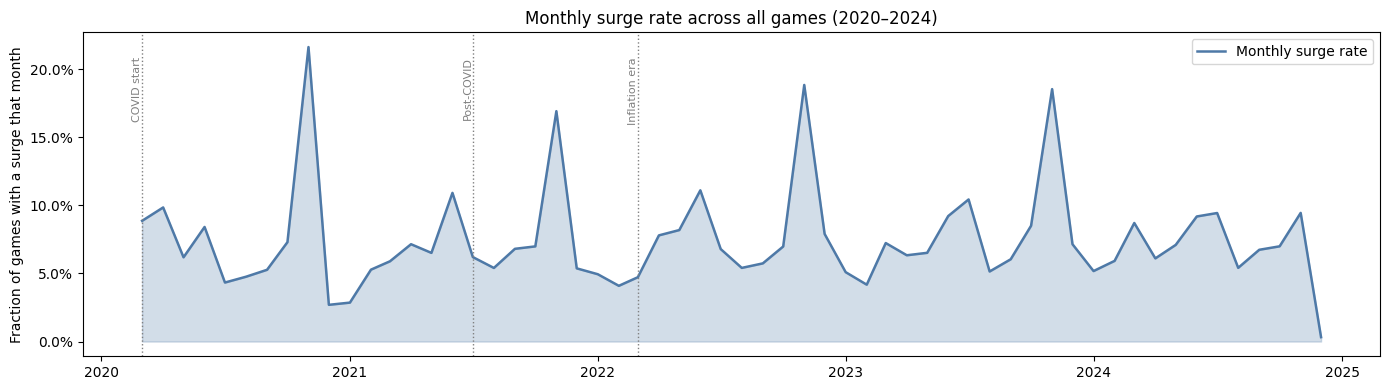

In [9]:
# Monthly surge rate over time
valid_weeks = df[df['roll_mean'].notna()].copy()

monthly_rate = (
    valid_weeks
    .groupby(valid_weeks['year_week'].dt.to_period('M'))
    .agg(
        total_obs  = ('is_surge', 'count'),
        surge_obs  = ('is_surge', 'sum')
    )
)
monthly_rate['surge_rate'] = monthly_rate['surge_obs'] / monthly_rate['total_obs']
monthly_rate.index = monthly_rate.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly_rate.index, monthly_rate['surge_rate'], alpha=0.25, color='#4e79a7')
ax.plot(monthly_rate.index, monthly_rate['surge_rate'],
        color='#4e79a7', linewidth=1.8, label='Monthly surge rate')

# Mark economic period boundaries
for xval, label in [
    ('2020-03-01', 'COVID start'),
    ('2021-07-01', 'Post-COVID'),
    ('2022-03-01', 'Inflation era'),
]:
    ax.axvline(pd.Timestamp(xval), color='gray', linestyle=':', linewidth=1)
    ax.text(pd.Timestamp(xval), ax.get_ylim()[1] * 0.92, label,
            rotation=90, va='top', ha='right', fontsize=8, color='gray')

ax.set_title('Monthly surge rate across all games (2020–2024)', fontsize=12)
ax.set_ylabel('Fraction of games with a surge that month')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

## 8.3 Diagnostic 3 — Spot-Check a Specific Game

Pick a well-known game and visually confirm the flagged weeks correspond to
real events (a patch, a viral moment, a review-bomb).

**How to use this:** Change `SPOT_CHECK_ID` to any appID in your dataset.
Good candidates are games where you know the history — e.g. CS2 (730),
Cyberpunk 2077 (1091500), Elden Ring (1245620).
If the default (most-reviewed game) shows sensible surges, your detection is working.


In [10]:
# Find Persona 5 Royal's appID first
persona = df[df['name'].str.contains('Persona 5', case=False, na=False)][['appID', 'name']].drop_duplicates()
print(persona)

          appID               name
375743  1687950    Persona 5 Royal
491579  2254740  Persona 5 Tactica


Spot-checking: Persona 5 Royal (appID: 1687950)
Total weeks       : 112
Surge weeks       : 8
Surge rate        : 7.14%


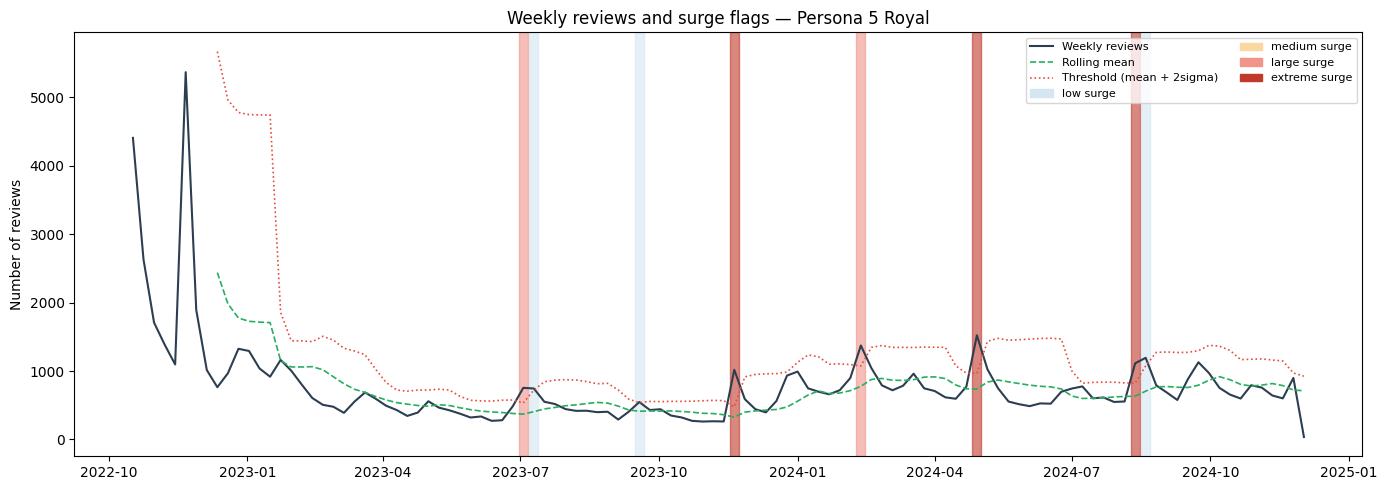


Surge weeks for manual verification:
 year_week  n_reviews  roll_mean  sigma_above surge_intensity
2023-07-03        754   370.2500       4.7192           large
2023-07-10        745   406.3750       2.1470             low
2023-09-18        547   412.6250       2.1536             low
2023-11-20       1018   325.8750       9.2202         extreme
2024-02-12       1373   776.2500       4.0073           large
2024-04-29       1522   737.8750       6.9242         extreme
2024-08-12       1113   632.1250       5.0541         extreme
2024-08-19       1193   705.8750       2.6352             low


In [11]:
# Change this to any appID you want to inspect
SPOT_CHECK_ID = '1687950'   # PERSONa 5 Royal

game_df   = df[df['appID'] == SPOT_CHECK_ID].copy()
game_name = game_df['name'].iloc[0] if 'name' in game_df.columns else SPOT_CHECK_ID

print(f'Spot-checking: {game_name} (appID: {SPOT_CHECK_ID})')
print(f'Total weeks       : {len(game_df)}')
print(f'Surge weeks       : {game_df["is_surge"].sum()}')
print(f'Surge rate        : {game_df["is_surge"].mean():.2%}')

fig, ax = plt.subplots(figsize=(14, 5))

# Shade surge weeks by intensity
color_map = {'low': '#d4e6f1', 'medium': '#fad7a0', 'large': '#f1948a', 'extreme': '#c0392b'}
for _, row in game_df[game_df['is_surge']].iterrows():
    ax.axvspan(
        row['year_week'] - pd.Timedelta(days=3),
        row['year_week'] + pd.Timedelta(days=3),
        color=color_map.get(row['surge_intensity'], '#d4e6f1'),
        alpha=0.6
    )

ax.plot(game_df['year_week'], game_df['n_reviews'],
        color='#2c3e50', linewidth=1.5, label='Weekly reviews')
ax.plot(game_df['year_week'], game_df['roll_mean'],
        color='#27ae60', linewidth=1.2, linestyle='--', label='Rolling mean')
ax.plot(game_df['year_week'], game_df['surge_threshold'],
        color='#e74c3c', linewidth=1.2, linestyle=':', label=f'Threshold (mean + {MULTIPLIER}sigma)')

ax.set_title(f'Weekly reviews and surge flags — {game_name}', fontsize=12)
ax.set_ylabel('Number of reviews')

legend_patches = [
    mpatches.Patch(color='#d4e6f1', label='low surge'),
    mpatches.Patch(color='#fad7a0', label='medium surge'),
    mpatches.Patch(color='#f1948a', label='large surge'),
    mpatches.Patch(color='#c0392b', label='extreme surge'),
]
ax.legend(handles=list(ax.lines) + legend_patches, loc='upper right', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('surge_diagnostic_3_spotcheck.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the actual surge weeks for manual verification
print('\nSurge weeks for manual verification:')
surge_weeks = game_df[game_df['is_surge']][['year_week','n_reviews','roll_mean','sigma_above','surge_intensity']]
print(surge_weeks.to_string(index=False))

The launch period (Oct 2022 – Jan 2023)

The massive spike at launch is correctly not flagged as a surge. This is the rolling window working exactly as designed — there's no prior baseline to compare against in the first 8 weeks, so the launch peak is excluded by construction. This is the feature you documented in your thesis. The threshold line (red dotted) is extremely high during this period because the rolling mean is being anchored to those enormous early numbers.

The flagged surges — do they match real events?
June/July 2023 — large surge (red): This almost certainly corresponds to the Steam Summer Sale 2023, which ran late June. Persona 5 Royal would have been heavily discounted, bringing in a wave of new players. Clean, explainable.
September 2023 — low surge (blue): Likely a smaller promotion or a content update. Worth a quick Google search of "Persona 5 Royal PC September 2023" to confirm.
December 2023 — extreme surge (dark red): Two likely explanations — Steam Winter Sale 2023 combined with the broader Persona series getting attention around Persona 3 Reload's announcement and marketing ramp-up ahead of its February 2024 launch. Players interested in Persona 3 Reload were likely going back to play Persona 5 Royal first.
February/March 2024 — large surge (red): Almost certainly the Persona 3 Reload release in February 2024. A major new entry in the same franchise drives players to review the previous game — a classic information cascade effect across a game series.
April 2024 — extreme surge (dark red): Possibly the Persona 3 Reload DLC announcement or the broader Atlus sale that typically follows a major release.
July/August 2024 — extreme + low (red and blue): Steam Summer Sale 2024.

---
# 9. Descriptive Preview — Surge vs Non-Surge Satisfaction

This is a **descriptive** comparison only — not causal inference.
The panel regression in Stage 3 will control for game fixed effects and time fixed effects
to isolate the causal effect. This section just gives you a sense of the raw patterns
before controlling for anything.

**Important caveat:** Any difference you see here conflates surge effects with
selection bias — games that surge tend to be higher-quality games, which would also
have higher pos_share regardless of the surge. This is exactly the confound that
fixed effects regression addresses in Stage 3.


In [12]:
valid_df = df[df['roll_mean'].notna()].copy()

surge_sat  = valid_df[valid_df['is_surge']]['pos_share'].dropna()
normal_sat = valid_df[~valid_df['is_surge']]['pos_share'].dropna()

from scipy import stats
t_stat, p_val = stats.ttest_ind(surge_sat, normal_sat)
effect_size   = (surge_sat.mean() - normal_sat.mean()) / valid_df['pos_share'].std()

print('DESCRIPTIVE COMPARISON: Surge vs Non-Surge Periods')
print('=' * 55)
print(f'Mean pos_share (surge)   : {surge_sat.mean() * 100:.2f}%')
print(f'Mean pos_share (normal)  : {normal_sat.mean() * 100:.2f}%')
print(f'Raw difference           : {(surge_sat.mean() - normal_sat.mean()) * 100:.2f} pp')
print(f'Effect size (Cohen d)    : {effect_size:.3f}')
print(f'T-statistic              : {t_stat:.4f}')
print(f'P-value                  : {p_val:.4f}')
print()
print('NOTE: This raw difference includes selection bias.')
print('The fixed effects regression in Stage 3 will isolate the causal effect.')

DESCRIPTIVE COMPARISON: Surge vs Non-Surge Periods
Mean pos_share (surge)   : 81.96%
Mean pos_share (normal)  : 81.05%
Raw difference           : 0.91 pp
Effect size (Cohen d)    : 0.035
T-statistic              : 7.2277
P-value                  : 0.0000

NOTE: This raw difference includes selection bias.
The fixed effects regression in Stage 3 will isolate the causal effect.


## 9.2 Satisfaction by Surge Intensity

This shows whether more intense surges are associated with higher or lower satisfaction.
A non-monotonic pattern here (e.g. medium surges positive, extreme surges negative)
is early evidence of the U-shaped relationship your professor mentioned.
Again, this is purely descriptive — Stage 3 controls for confounds.


                 mean_pct  median    std   count
surge_intensity                                 
no_surge          81.0486  0.9211 0.2658  559790
low               81.3533  0.8642 0.2011   19429
medium            81.3969  0.8667 0.1976    9853
large             82.8122  0.8750 0.1744    4599
extreme           83.0046  0.8964 0.1959   12760


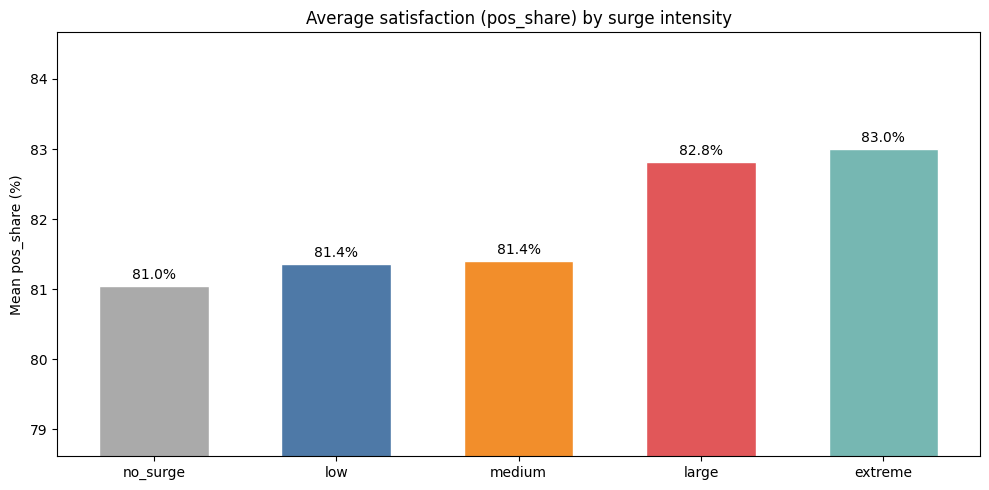

In [13]:
intensity_stats = (
    valid_df.groupby('surge_intensity')['pos_share']
    .agg(mean='mean', median='median', std='std', count='count')
    .reindex(['no_surge', 'low', 'medium', 'large', 'extreme'])
)
intensity_stats['mean_pct'] = intensity_stats['mean'] * 100
print(intensity_stats[['mean_pct', 'median', 'std', 'count']].round(4))

fig, ax = plt.subplots(figsize=(10, 5))
cats   = ['no_surge', 'low', 'medium', 'large', 'extreme']
colors = ['#aaaaaa', '#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
means  = [intensity_stats.loc[c, 'mean_pct'] if c in intensity_stats.index else 0 for c in cats]

bars = ax.bar(cats, means, color=colors, edgecolor='white', width=0.6)
ax.set_title('Average satisfaction (pos_share) by surge intensity', fontsize=12)
ax.set_ylabel('Mean pos_share (%)')
ax.set_ylim(min(means) * 0.97, max(means) * 1.02)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('surge_diagnostic_4_intensity_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.3 Surge Rate by Macroeconomic Period

Does the frequency of surges differ across the COVID, inflation, and baseline periods?
And does the satisfaction difference between surge and non-surge weeks vary by period?
This is the first look at the moderation hypothesis before the formal regression.


In [14]:
if 'period' in valid_df.columns:
    period_summary = (
        valid_df.groupby('period')
        .agg(
            total_obs    = ('is_surge', 'count'),
            surge_obs    = ('is_surge', 'sum'),
            mean_sat_all = ('pos_share', 'mean'),
        )
    )
    period_summary['surge_rate'] = period_summary['surge_obs'] / period_summary['total_obs']

    surge_sat_period  = valid_df[valid_df['is_surge']].groupby('period')['pos_share'].mean()
    normal_sat_period = valid_df[~valid_df['is_surge']].groupby('period')['pos_share'].mean()

    period_summary['surge_sat']  = surge_sat_period
    period_summary['normal_sat'] = normal_sat_period
    period_summary['sat_diff_pp'] = (
        (period_summary['surge_sat'] - period_summary['normal_sat']) * 100
    ).round(3)

    print('Surge and satisfaction by macroeconomic period:')
    print(period_summary[['total_obs','surge_rate','normal_sat','surge_sat','sat_diff_pp']]
          .reindex(['baseline','covid','post_covid','inflation'])
          .round(4)
          .to_string())
    print()
    print('sat_diff_pp = (surge pos_share - normal pos_share) in percentage points')
    print('Negative = surges associated with lower satisfaction in that period')

Surge and satisfaction by macroeconomic period:
            total_obs  surge_rate  normal_sat  surge_sat  sat_diff_pp
period                                                               
baseline       208844      0.0726      0.7999     0.8002       0.0340
covid           61291      0.0746      0.8334     0.8455       1.2130
post_covid      63047      0.0724      0.8224     0.8383       1.5850
inflation      273249      0.0818      0.8107     0.8236       1.2870

sat_diff_pp = (surge pos_share - normal pos_share) in percentage points
Negative = surges associated with lower satisfaction in that period


Descriptively, surge weeks are associated with marginally higher satisfaction than non-surge weeks (0.91 percentage points, Cohen's d = 0.035), suggesting a statistically significant but practically modest raw relationship. This association strengthens considerably when disaggregated by macroeconomic period — surge effects on satisfaction are negligible during the baseline period (+0.03pp) but substantially larger during COVID (+1.21pp), post-COVID (+1.59pp), and inflation (+1.29pp) periods. However, these descriptive differences conflate surge effects with game quality selection bias, as higher-quality games are more likely to experience surges and also command higher satisfaction ratings independently. Panel regression with game and time fixed effects in the following section isolates the within-game causal effect.

---
# 10. Final Dataset Summary

Before saving, confirm the key variables look reasonable.
The file saved here is the input for Stage 3 (panel regression).
Never proceed to regression before checking these numbers.


In [15]:
print(f'Total rows               : {len(df):,}')
print(f'Unique games             : {df["appID"].nunique():,}')
print(f'Date range               : {df["year_week"].min().date()}  to  {df["year_week"].max().date()}')
print()

valid_df2 = df[df['roll_mean'].notna()]
print(f'Rows with valid baseline : {len(valid_df2):,}')
print(f'Total surge weeks        : {valid_df2["is_surge"].sum():,}')
print(f'Overall surge rate       : {valid_df2["is_surge"].mean():.2%}')
print()

print('Surge intensity breakdown (surge weeks only):')
surge_only2 = df[df['is_surge']]
for cat in ['low', 'medium', 'large', 'extreme']:
    n   = (surge_only2['surge_intensity'] == cat).sum()
    pct = n / len(surge_only2) * 100
    print(f'  {cat:<10}: {n:>6,}  ({pct:.1f}% of surges)')

print()
print('Missing pos_share in surge weeks:')
missing_dv_surge = surge_only2['pos_share'].isna().mean()
print(f'  {missing_dv_surge:.2%}')
if missing_dv_surge > 0.05:
    print('  WARNING: >5% missing — investigate before regression.')

Total rows               : 657,599
Unique games             : 6,396
Date range               : 2020-01-06  to  2024-12-02

Rows with valid baseline : 606,431
Total surge weeks        : 46,641
Overall surge rate       : 7.69%

Surge intensity breakdown (surge weeks only):
  low       : 19,429  (41.7% of surges)
  medium    :  9,853  (21.1% of surges)
  large     :  4,599  (9.9% of surges)
  extreme   : 12,760  (27.4% of surges)

Missing pos_share in surge weeks:
  0.00%


---
# 11. Save the Surge-Flagged Panel

This file is the single input for Stage 3 (panel regression).
It contains all Stage 1 columns plus the surge detection columns added here.

| New column | What it is |
|---|---|
| `roll_mean` | 8-week rolling mean of n_reviews (the baseline) |
| `roll_std` | 8-week rolling std of n_reviews |
| `surge_threshold` | roll_mean + 2 x roll_std |
| `is_surge` | Boolean — whether this week is a surge |
| `sigma_above` | Magnitude of surge in std devs above the rolling mean |
| `surge_intensity` | Category: no_surge / low / medium / large / extreme |


In [16]:
df.to_csv(OUTPUT_PATH, index=False)
print(f'Saved   : {OUTPUT_PATH}')
print(f'Shape   : {df.shape}')

# Verify read-back
verify = pd.read_csv(OUTPUT_PATH, nrows=5)
print(f'Surge columns present: {[c for c in ["is_surge","sigma_above","surge_intensity"] if c in verify.columns]}')

Saved   : drive/My Drive/Notebooks/PersonalResearch/panel_with_surges_weekly.csv
Shape   : (657599, 27)
Surge columns present: ['is_surge', 'sigma_above', 'surge_intensity']
